In [ ]:
!pip install nbformat

In [21]:
import pandas as pd

data = {
"x1":[0.5,1,1.2,2,2.5,3,0.5,1,1.5,2,2.5,3,3.5,4,4.5,1.8,2.2,3.2,0.8,4.2],
"x2":[0.5,0.8,1.0,0.5,0.7,0.4,3.8,3.2,3.0,2.5,2.2,2.0,1.8,1.5,1.2,1.0,0.9,0.7,1.0,0.5],
"y":[0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0]
}

df = pd.DataFrame(data)


In [22]:
df.head(5)

,x1,x2,y
0,0.5,0.5,0
1,1.0,0.8,0
2,1.2,1.0,0
3,2.0,0.5,0
4,2.5,0.7,0


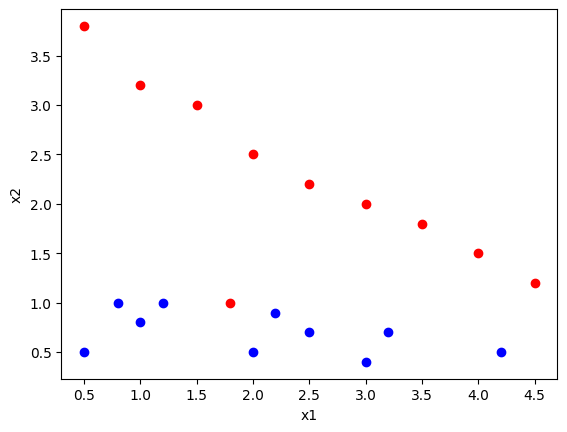

In [24]:
import matplotlib.pyplot as plt

plt.scatter(df[df.y==0].x1, df[df.y==0].x2, color='blue')
plt.scatter(df[df.y==1].x1, df[df.y==1].x2, color='red')
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

##This data looks linearly separable, so we can apply logistic regression.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
# Features and target
X = df[['x1', 'x2']]
y = df['y']

# Initialize and train the logistic regression model
model = LogisticRegression()
model.fit(X, y)


LogisticRegression()

In [26]:
y_pred = model.predict(X)

# Evaluate
accuracy = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(cm)

Accuracy: 0.95
Confusion Matrix:
[[10  0]
 [ 1  9]]


In [27]:
print("Coefficients (weights):", model.coef_)
print("Intercept (bias):", model.intercept_)

Coefficients (weights): [[0.55927698 1.87310407]]
Intercept (bias): [-3.88582387]


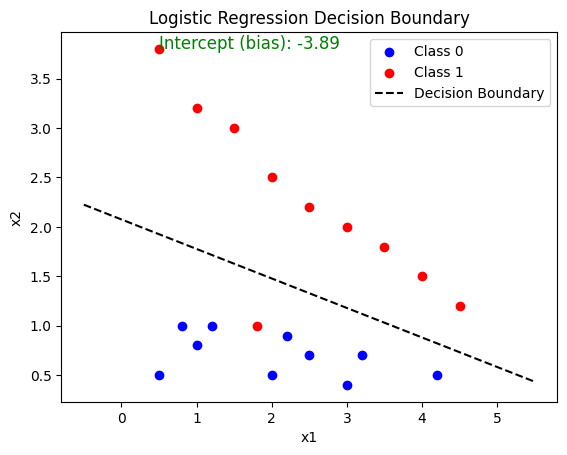

In [28]:
# Plot points
plt.scatter(df[df.y==0].x1, df[df.y==0].x2, color='blue', label='Class 0')
plt.scatter(df[df.y==1].x1, df[df.y==1].x2, color='red', label='Class 1')

# Decision boundary: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b)/w2
w = model.coef_[0]
b = model.intercept_[0]
x_values = np.linspace(df.x1.min() - 1, df.x1.max() + 1, 200)
y_values = -(w[0]*x_values + b)/w[1]

plt.plot(x_values, y_values, 'k--', label='Decision Boundary')

# Annotate intercept on the plot
plt.text(df.x1.min(), df.x2.max(), f"Intercept (bias): {b:.2f}", fontsize=12, color='green')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.show()


---

## Logistic Regression – Mathematical Formulation

### 1. Linear Model

First compute a linear combination of the input features:

$$
z = wX + b
$$

Where:

* $X$ = input feature
* $w$ = weight
* $b$ = bias

---

### 2. Sigmoid Function

In **Logistic Regression**, the linear output is converted into a probability using the sigmoid function.

$$
\hat{y} = \sigma(z)
$$

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Final model:

$$
\hat{y} = \frac{1}{1 + e^{-(wX + b)}}
$$

Where:

* $\hat{y}$ = predicted probability

---

### 3. Loss Function (Log Loss)

Logistic regression uses binary cross-entropy loss.

$$
J = -\frac{1}{m}\sum_{i=1}^{m} \left[ y_i \log(\hat{y_i}) + (1-y_i)\log(1-\hat{y_i}) \right]
$$

Where:

* $m$ = number of samples
* $y$ = actual value
* $\hat{y}$ = predicted probability

---

### 4. Gradient Descent Updates

Using **Gradient Descent**, parameters are updated iteratively.

Weight update:

$$
w = w - \alpha \frac{1}{m} X^T(\hat{y} - y)
$$

Bias update:

$$
b = b - \alpha \frac{1}{m}\sum(\hat{y} - y)
$$

Where:

* $\alpha$ = learning rate

---

### 5. Training Procedure

Steps:

1. Initialize $w$ and $b$
2. Compute $z = wX + b$
3. Apply sigmoid to get prediction $\hat{y}$
4. Compute gradients
5. Update parameters using gradient descent
6. Repeat for many iterations

---


Epoch 0 Loss: 0.6931
Epoch 100 Loss: 0.4411
Epoch 200 Loss: 0.3640
Epoch 300 Loss: 0.3144
Epoch 400 Loss: 0.2801
Epoch 500 Loss: 0.2552
Epoch 600 Loss: 0.2366
Epoch 700 Loss: 0.2221
Epoch 800 Loss: 0.2106
Epoch 900 Loss: 0.2012
Trained weights: [0.36070807 3.24256976]
Trained bias: -4.657156676963631
Training accuracy: 0.95


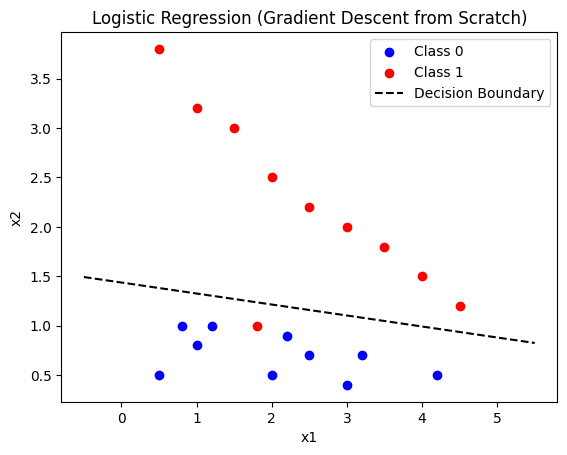

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
data = {
    "x1": [0.5,1,1.2,2,2.5,3,0.5,1,1.5,2,2.5,3,3.5,4,4.5,1.8,2.2,3.2,0.8,4.2],
    "x2": [0.5,0.8,1.0,0.5,0.7,0.4,3.8,3.2,3.0,2.5,2.2,2.0,1.8,1.5,1.2,1.0,0.9,0.7,1.0,0.5],
    "y":  [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0]
}
df = pd.DataFrame(data)

# Prepare features and target
X = df[['x1', 'x2']].values   # shape (20,2)
y = df['y'].values            # shape (20,)

# Add intercept term by appending a column of ones (optional; here we treat bias separately)
m, n = X.shape

# Initialize weights and bias
w = np.zeros(n)
b = 0

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Learning parameters
lr = 0.1
epochs = 1000

# Gradient Descent Loop
for i in range(epochs):
    # Linear output
    z = np.dot(X, w) + b      # shape (m,)
    y_pred = sigmoid(z)       # predicted probabilities

    # Compute gradients (vectorized)
    dw = (1/m) * np.dot(X.T, (y_pred - y))   # shape (n,)
    db = (1/m) * np.sum(y_pred - y)

    # Update weights and bias
    w = w - lr * dw
    b = b - lr * db

    # Optional: print loss every 100 iterations
    if i % 100 == 0:
        loss = - (1/m) * np.sum(y*np.log(y_pred + 1e-15) + (1-y)*np.log(1 - y_pred + 1e-15))
        print(f"Epoch {i} Loss: {loss:.4f}")

print(f"Trained weights: {w}")
print(f"Trained bias: {b}")

# Predict labels (threshold at 0.5)
y_pred_labels = (sigmoid(np.dot(X, w) + b) >= 0.5).astype(int)

# Accuracy
accuracy = np.mean(y_pred_labels == y)
print(f"Training accuracy: {accuracy:.2f}")

# Plot data points
plt.scatter(df[df.y==0].x1, df[df.y==0].x2, color='blue', label='Class 0')
plt.scatter(df[df.y==1].x1, df[df.y==1].x2, color='red', label='Class 1')

# Decision boundary line: solve for x2 in w1*x1 + w2*x2 + b = 0
x_vals = np.linspace(df.x1.min()-1, df.x1.max()+1, 200)
y_vals = -(w[0]*x_vals + b) / w[1]

plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression (Gradient Descent from Scratch)')
plt.legend()
plt.show()